# Etapa 1 - Analiza datelor de intrare

In aceasta parte a proiectului analizam datele procesate anterior. Scopul este sa intelegem structura CV-urilor, cate skill-uri au fost extrase si care sunt cele mai frecvente competente identificate.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import ast

## Incarcarea datelor procesate

Incarcam fisierul CSV generat dupa curatarea CV-urilor si extragerea skill-urilor.

In [2]:
df = pd.read_csv("processed_resumes.csv")

df.head()

,resume_text,clean_resume,skills_found,num_skills
0,"{""name"":""Unknown"",""email"":""Unknown"",""phone"":""U...",name unknown email unknown phone unknown locat...,"['python', 'c++', 'sql', 'mysql', 'tensorflow'...",7
1,"{""name"":""Unknown"",""email"":""Unknown"",""phone"":""U...",name unknown email unknown phone unknown locat...,[],0
2,"{""name"":""Not Provided"",""email"":""Not Provided"",...",name not provided email not provided phone not...,"['git', 'github']",2
3,"{""name"":""Unknown"",""email"":""Unknown"",""phone"":""U...",name unknown email unknown phone unknown locat...,[],0
4,"{""name"":"""",""email"":"""",""phone"":"""",""location"":{""...",name email phone location city pune country in...,"['git', 'github']",2


## Informatii generale despre dataset

Verificam numarul de CV-uri, coloanele existente si daca exista valori lipsa.

In [3]:
print("Numar CV-uri:", len(df))
print("Coloane:", df.columns.tolist())
print(df.isnull().sum())

Numar CV-uri: 1000
Coloane: ['resume_text', 'clean_resume', 'skills_found', 'num_skills']
resume_text     1
clean_resume    1
skills_found    0
num_skills      0
dtype: int64


## Analiza numarului de skill-uri

Analizam cate skill-uri au fost gasite in fiecare CV.

In [4]:
print("Numar mediu skill-uri:", df["num_skills"].mean())
print("Numar maxim skill-uri:", df["num_skills"].max())
print("Numar minim skill-uri:", df["num_skills"].min())

Numar mediu skill-uri: 2.909
Numar maxim skill-uri: 8
Numar minim skill-uri: 0


## Grafic: distributia numarului de skill-uri

Acest grafic arata cate CV-uri au 0, 1, 2 sau mai multe skill-uri detectate.

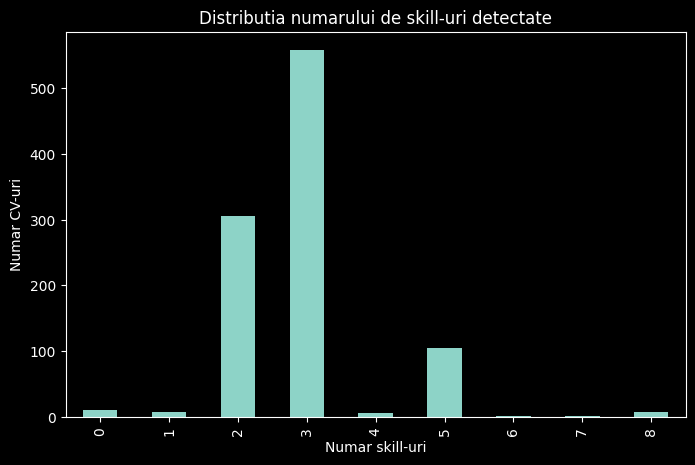

In [5]:
plt.figure(figsize=(8, 5))
df["num_skills"].value_counts().sort_index().plot(kind="bar")
plt.title("Distributia numarului de skill-uri detectate")
plt.xlabel("Numar skill-uri")
plt.ylabel("Numar CV-uri")
plt.show()

## Top skill-uri identificate

Transformam coloana cu skill-uri intr-o lista si calculam cele mai frecvente competente.

In [6]:
all_skills = []

for skills in df["skills_found"]:
    try:
        skills_list = ast.literal_eval(skills)
        all_skills.extend(skills_list)
    except:
        pass

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.items(),
    columns=["skill", "count"]
).sort_values(by="count", ascending=False)

top_skills.head(10)

,skill,count
6,github,982
5,git,982
7,java,239
0,python,234
16,react,200
10,javascript,106
17,docker,83
2,sql,15
11,machine learning,14
3,mysql,13


## Grafic: cele mai frecvente skill-uri

Acest grafic arata skill-urile care apar cel mai des in CV-urile analizate.

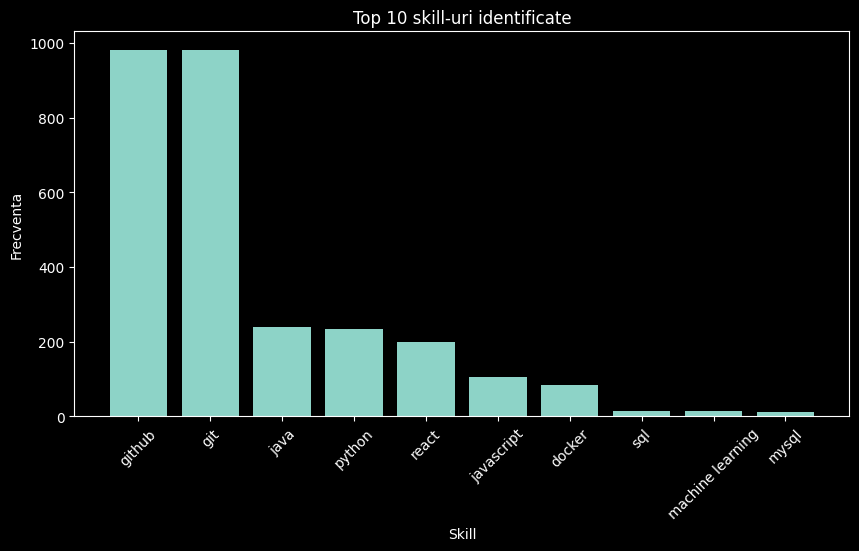

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(top_skills["skill"].head(10), top_skills["count"].head(10))
plt.title("Top 10 skill-uri identificate")
plt.xlabel("Skill")
plt.ylabel("Frecventa")
plt.xticks(rotation=45)
plt.show()

## Observatii finale

- Dataset-ul contine CV-uri in format text, procesate anterior.
- Unele CV-uri nu contin skill-uri detectabile.
- Cele mai frecvente skill-uri pot indica profilul general al candidatilor.
- Datele sunt nestructurate, ceea ce face necesara curatarea si procesarea textului.
- Aceasta analiza ajuta la pregatirea urmatoarei etape, unde se va dezvolta modelul AI pentru scorul de potrivire CV-job.